In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import torchvision
import torchvision.transforms as transforms
from torchvision import models
import torchvision.transforms.functional as TF

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [3]:
classes = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]

In [4]:
stats_stl10 = ((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
BATCH_SIZE = 64

transform_pt_train = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])
transform_pt_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])

testset_pt = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_pt_test)
loader_pt_test = torch.utils.data.DataLoader(testset_pt, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [5]:
def get_pretrained_model_optimized():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)

In [6]:
model_loaded = get_pretrained_model_optimized()
model_loaded.load_state_dict(torch.load('./models/model_resnet_stl10.pth', map_location=device))
model_loaded.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Funções de Avaliação

In [7]:
def show_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, 
                yticklabels=classes)
    
    plt.xlabel('Previsto')
    plt.ylabel('Verdadeiro')
    plt.title('Matriz de Confusão')
    plt.xticks(rotation=45)
    plt.show()

In [8]:
def get_all_predictions(model, loader, device):
    all_preds = []
    all_labels = []
    
    model.eval()  # Garante modo de avaliação
    
    print("Gerando predições para o conjunto de teste...")
    with torch.no_grad():
        for inputs, labels in tqdm(loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            # Traz de volta para CPU e converte para numpy
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

In [9]:
def show_classification_report(y_true, y_pred, classes, show_matrix=True):
    cr = classification_report(y_true, y_pred, target_names=classes, digits=4)
    print(cr)

    if show_matrix:
        show_confusion_matrix(y_true, y_pred, classes)

In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def calc_and_plot_ece(probs, labels, n_bins=15, title="Diagrama de Confiabilidade"):
    """
    Calcula o Expected Calibration Error (ECE) e plota o Reliability Diagram.
    
    Args:
        probs (Tensor): Probabilidades [N, n_classes] ou [N] (apenas a prob da classe predita).
        labels (Tensor): Rótulos verdadeiros [N].
        n_bins (int): Número de caixas (bins) para dividir as confianças.
    """
    # Garante que estamos na CPU e com numpy
    if isinstance(probs, torch.Tensor):
        probs = probs.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()

    # Se passamos todas as probabilidades, pegamos apenas a máxima (confiança da predição)
    # e a classe predita para comparar com o label
    if probs.ndim > 1:
        confidences = np.max(probs, axis=1)
        predictions = np.argmax(probs, axis=1)
    else:
        confidences = probs
        predictions = labels # Caso já tenha passado filtrado (menos comum)

    accuracies = predictions == labels

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    
    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    print(f"\n--- Calculando ECE ({title}) ---")

    for i in range(n_bins):
        # Define os limites do bin atual
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]

        # Filtra amostras que caem neste intervalo de confiança
        in_bin = np.logical_and(confidences > bin_lower, confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin) # Proporção de amostras neste bin

        if prop_in_bin > 0:
            # Acurácia média neste bin
            accuracy_in_bin = np.mean(accuracies[in_bin])
            # Confiança média neste bin
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            
            # ECE é a média ponderada da diferença absoluta |Acc - Conf|
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin

            # Guarda para plotar
            bin_accs.append(accuracy_in_bin)
            bin_confs.append(avg_confidence_in_bin)
            bin_counts.append(np.sum(in_bin))
        else:
            bin_accs.append(0)
            bin_confs.append(0)
            bin_counts.append(0)

    print(f"ECE Score: {ece:.4f} (Quanto menor, melhor)")

    # --- PLOTAGEM DO DIAGRAMA DE CONFIABILIDADE ---
    plt.figure(figsize=(6, 6))
    
    # Linha diagonal perfeita (Ideal)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfeitamente Calibrado')
    
    # Barras de acurácia por bin
    # O eixo X é a confiança média do bin, o eixo Y é a acurácia real
    plt.bar(bin_boundaries[1:], bin_accs, width=1.0/n_bins, align='edge', 
            edgecolor='black', alpha=0.7, label='Saída do Modelo', color='blue')
    
    # Barras da diferença (Gap de erro) - Opcional, mas visualmente informativo
    # Pinta de vermelho a parte "excedente" de confiança (Overconfidence)
    
    plt.xlabel('Confiança (Probabilidade Predita)')
    plt.ylabel('Acurácia Real')
    plt.title(f"{title}\nECE = {ece:.4f}")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    
    plt.savefig(f"ece_{title.lower().replace(' ', '_')}.png")
    plt.show()
    
    return ece

In [55]:
# Função auxiliar para coletar probs e labels do dataset inteiro
def get_logits_and_labels(model, loader, device, corruption_func=None, severity=0):
    all_probs = []
    all_labels = []
    model.eval()
    
    print("Coletando probabilidades...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            if corruption_func and severity > 0:
                inputs = corruption_func(inputs, severity)
            
            outputs = model(inputs)
            # Importante: Aplicar Softmax para ter probabilidades entre 0 e 1
            probs = torch.softmax(outputs, dim=1)
            
            all_probs.append(probs)
            all_labels.append(labels)
            
    return torch.cat(all_probs), torch.cat(all_labels)

In [75]:
def evaluate_model(model, loader, corruption_func, severities, device, stats=(), corruption_name="Teste"):
    """
    Avalia o modelo para uma lista de severidades de uma corrupção específica.
    Retorna uma lista de acurácias.
    """
    model.eval()
    accuracies = []
    
    print(f"\n>> Iniciando avaliação: {corruption_name}")
    
    for sev in severities:
        correct = 0
        total = 0
        
        # Itera sobre o dataset
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Aplica a corrupção (se sev == 0, a função deve retornar a original)
            if corruption_func:
                inputs = corruption_func(inputs, sev)
            
            with torch.no_grad():
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        acc = 100. * correct / total
        accuracies.append(acc)
        print(f"   Severidade {sev}: {acc:.2f}%")
        
    return accuracies

def plot_acc_curve(x_values, y_values, title, xlabel, color, filename):
    """
    Plota um gráfico de linha único e salva em arquivo.
    """
    plt.figure(figsize=(8, 6))
    
    # Plot principal
    plt.plot(x_values, y_values, marker='o', linestyle='-', color=color, linewidth=2, markersize=6)
    
    # Estilização
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Acurácia (%)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Define limites para ficar bonito (opcional, ajusta o eixo Y)
    plt.ylim(0, 105)
    
    # Salva e fecha para liberar memória
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"   [Gráfico salvo em: {filename}]")

In [ ]:
def plot_relative_robustness(clean_acc, corrupted_accs, severities, title, filename):
    """
    Plota a porcentagem de desempenho mantido em relação ao original.
    """
    # Calcula a % da acurácia original mantida
    # Ex: Original 80%, Corrompido 40% -> Retenção de 50%
    retention = [(acc / clean_acc) * 100 for acc in corrupted_accs]
    
    plt.figure(figsize=(8, 6))
    plt.plot(severities, retention, marker='s', linestyle='--', color='purple', label='Taxa de Retenção')
    
    # Linha de referência de 100%
    plt.axhline(y=100, color='gray', linestyle=':', alpha=0.5)
    
    plt.title(f"{title} (Retenção Relativa)", fontsize=14)
    plt.xlabel("Severidade da Corrupção", fontsize=12)
    plt.ylabel("% da Acurácia Original Mantida", fontsize=12)
    plt.grid(True, alpha=0.5)
    plt.ylim(0, 110)
    plt.legend()
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"   [Gráfico de retenção salvo em: {filename}]")

## Funções de Corrupção de Imagem

In [85]:
def apply_gaussian_noise(tensor, severity):
    """
    Adiciona ruído gaussiano.
    severity: Desvio padrão do ruído (ex: 0.1 a 1.0)
    """
    if severity == 0: return tensor
    noise = torch.randn_like(tensor) * severity
    return tensor + noise

def apply_blur(tensor, severity):
    """
    Aplica desfoque gaussiano.
    severity: Tamanho do kernel (deve ser ímpar, ex: 1, 3, 5, 7)
    """
    if severity <= 0: return tensor
    
    kernel_size = severity
    return TF.gaussian_blur(tensor, kernel_size=[kernel_size, kernel_size], sigma=[severity])

def apply_darkness(tensor, severity):
    """
    Simula ambiente escuro reduzindo a intensidade dos pixels.
    severity: 0.0 (original) a 1.0 (totalmente preto)
    """
    if severity == 0: return tensor

    stats = stats_stl10
    
    mean, std = stats
    mean = torch.tensor(mean).view(3, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(3, 1, 1).to(tensor.device)
    
    # 1. Desnormalizar (voltar para 0..1)
    # Clonamos para não alterar o original
    x = tensor.clone() * std + mean
    
    # 2. Aplicar o fator de escurecimento (Multiplicação é melhor que subtração)
    # Se severity=0 -> fator=1 (mantém)
    # Se severity=1 -> fator=0 (preto total)
    factor = 1.0 - severity
    x = x * factor
    
    # 3. Renormalizar
    x = (x - mean) / std
    
    return x

## Avaliação no Teste

In [11]:
y_true, y_pred = get_all_predictions(model_loaded, loader_pt_test, device)

Gerando predições para o conjunto de teste...


100%|██████████| 125/125 [00:10<00:00, 12.34it/s]


              precision    recall  f1-score   support

    airplane     0.9738    0.9762    0.9750       800
        bird     0.9554    0.9637    0.9596       800
         car     0.9725    0.9738    0.9731       800
         cat     0.9168    0.9087    0.9127       800
        deer     0.9701    0.9337    0.9516       800
         dog     0.9124    0.9113    0.9118       800
       horse     0.9414    0.9637    0.9524       800
      monkey     0.9399    0.9575    0.9486       800
        ship     0.9703    0.9788    0.9745       800
       truck     0.9682    0.9525    0.9603       800

    accuracy                         0.9520      8000
   macro avg     0.9521    0.9520    0.9520      8000
weighted avg     0.9521    0.9520    0.9520      8000



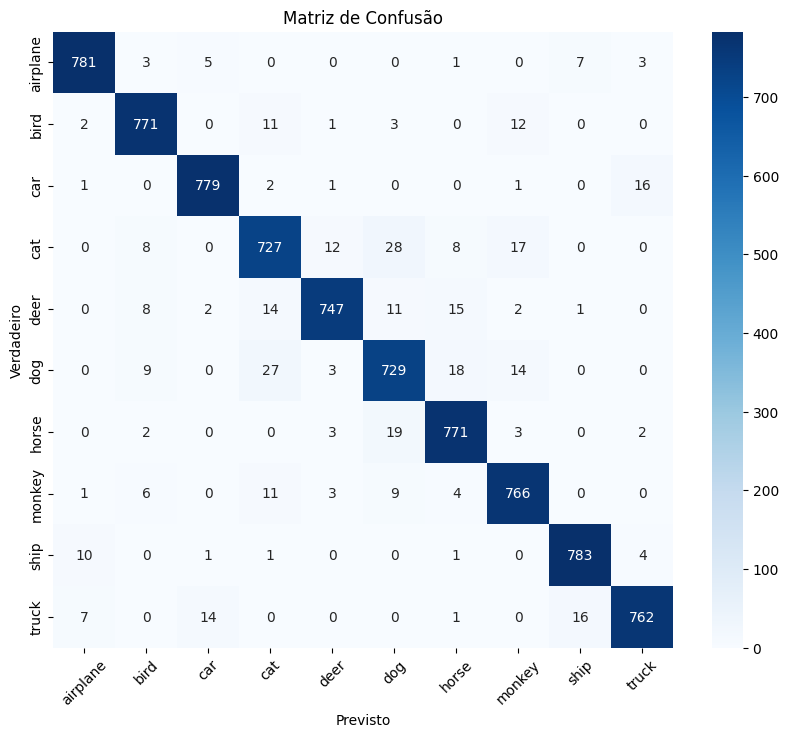

In [12]:
show_classification_report(y_true, y_pred, classes)

In [91]:
def visualize_corruptions(loader, stats, tests, img_idx=0):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    img = images[img_idx].to(device) # Pega a primeira imagem
    
    plt.figure(figsize=(15, 4))
    mean, std = stats
    
    for i, (name, func, sev) in enumerate(tests):
        # Aplica corrupção (se houver função)
        corrupted = func(img.unsqueeze(0), sev) if func else img.unsqueeze(0)
        corrupted = corrupted.squeeze(0).cpu()
        
        # Desnormaliza para plotar bonito
        img_show = corrupted.clone()
        for t, m, s in zip(img_show, mean, std):
            t.mul_(s).add_(m)
            
        np_img = img_show.numpy().transpose((1, 2, 0))
        np_img = np.clip(np_img, 0, 1) # Garante intervalo válido
        
        plt.subplot(1, len(tests), i+1)
        plt.imshow(np_img)
        plt.title(f"{name}\nSev: {sev}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

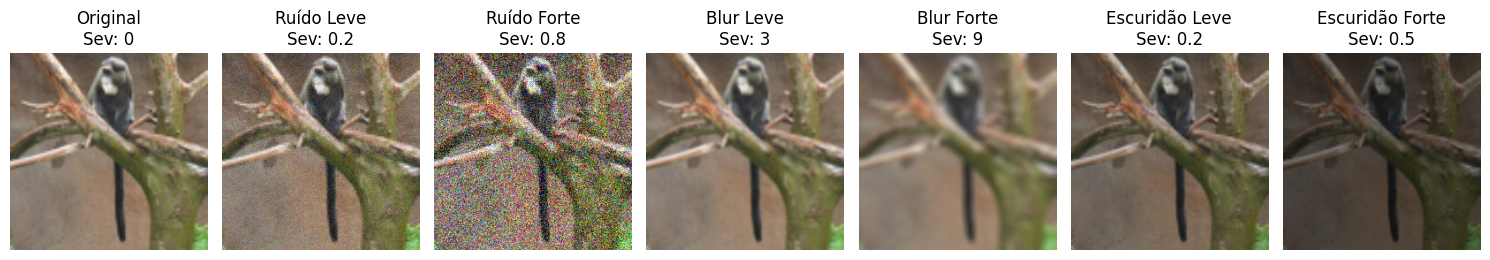

In [68]:
# Lista de testes para visualizar
tests = [
    ("Original", None, 0),
    ("Ruído Leve", apply_gaussian_noise, 0.2),
    ("Ruído Forte", apply_gaussian_noise, 0.8),
    ("Blur Leve", apply_blur, 3),
    ("Blur Forte", apply_blur, 9),
    ("Escuridão Leve", apply_darkness, 0.2),
    ("Escuridão Forte", apply_darkness, 0.5),
]

visualize_corruptions(loader_pt_test, stats_stl10, tests, img_idx=1)

Coletando probabilidades...

--- Calculando ECE (Calibração Original) ---
ECE Score: 0.0166 (Quanto menor, melhor)


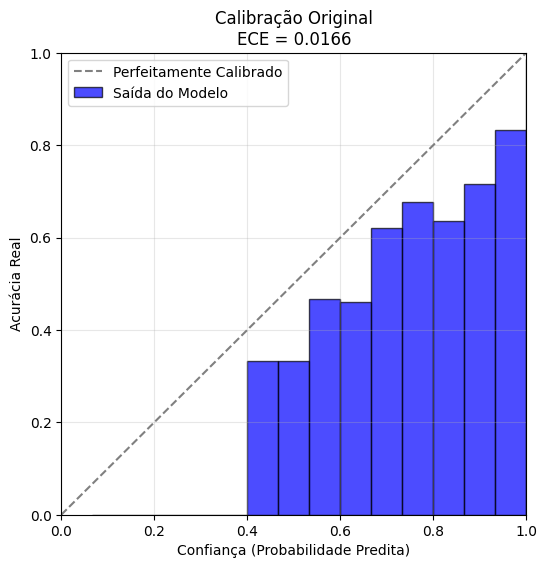

In [57]:
probs_clean, labels_clean = get_logits_and_labels(model_loaded, loader_pt_test, device)
ece_clean = calc_and_plot_ece(probs_clean, labels_clean, title="Calibração Original")

## Teste de Ruído Gaussiano

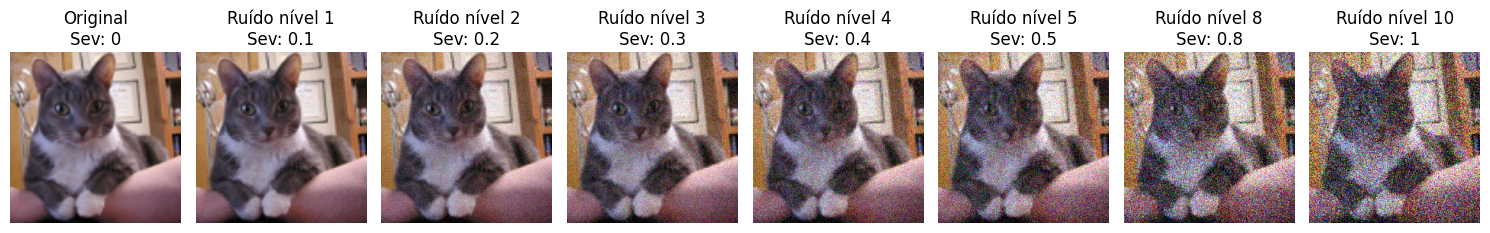

In [24]:
# Lista de testes para visualizar
tests_noise = [
    ("Original", None, 0),
    ("Ruído nível 1", apply_gaussian_noise, 0.1),
    ("Ruído nível 2", apply_gaussian_noise, 0.2),
    ("Ruído nível 3", apply_gaussian_noise, 0.3),
    ("Ruído nível 4", apply_gaussian_noise, 0.4),
    ("Ruído nível 5", apply_gaussian_noise, 0.5),
    ("Ruído nível 8", apply_gaussian_noise, 0.8),
    ("Ruído nível 10", apply_gaussian_noise, 1)
]

visualize_corruptions(loader_pt_test, stats_stl10, tests_noise, img_idx=4)

In [25]:
severities_noise = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,  0.9, 1]

# 1. Avaliar
acc_noise = evaluate_model(
    model=model_loaded,
    loader=loader_pt_test,
    corruption_func=apply_gaussian_noise,
    severities=severities_noise,
    device=device,
    corruption_name="Ruído Gaussiano"
)


>> Iniciando avaliação: Ruído Gaussiano
   Severidade 0.0: 95.20%
   Severidade 0.1: 94.14%
   Severidade 0.2: 91.21%
   Severidade 0.3: 85.79%
   Severidade 0.4: 78.24%
   Severidade 0.5: 69.47%
   Severidade 0.6: 60.17%
   Severidade 0.7: 51.83%
   Severidade 0.8: 44.42%
   Severidade 0.9: 38.20%
   Severidade 1: 31.19%


   [Gráfico salvo em: images/resultado_robustez_ruido.png]


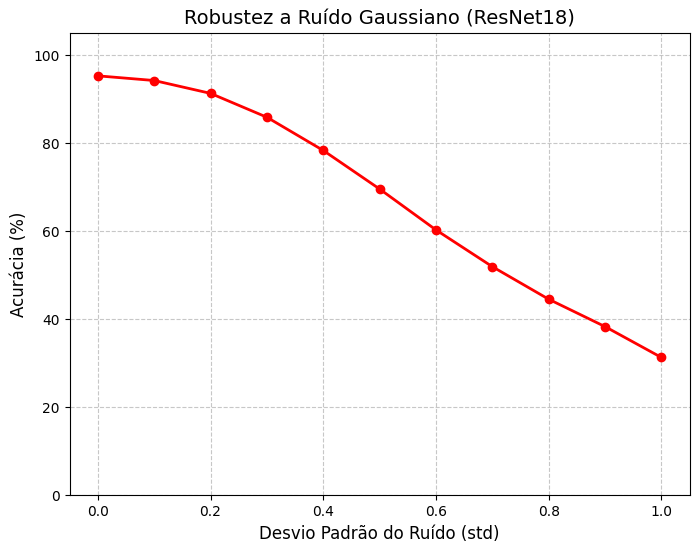

In [34]:
# 2. Plotar e Salvar
plot_acc_curve(
    x_values=severities_noise,
    y_values=acc_noise,
    title="Robustez a Ruído Gaussiano (ResNet18)",
    xlabel="Desvio Padrão do Ruído (std)",
    color='red',
    filename='images/resultado_robustez_ruido.png'
)

   [Gráfico de retenção salvo em: images/robustez_relativa_ruido.png]


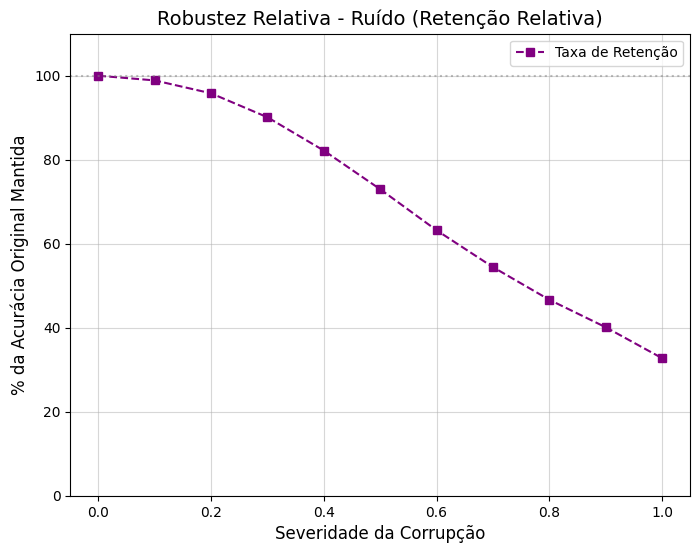

In [35]:
# O primeiro elemento das listas (severities_noise[0]) é o baseline (severidade 0)
baseline_acc = acc_noise[0] 

# Chamada da função
plot_relative_robustness(
    clean_acc=baseline_acc, 
    corrupted_accs=acc_noise, 
    severities=severities_noise,
    title="Robustez Relativa - Ruído", 
    filename="images/robustez_relativa_ruido.png"
)

Coletando probabilidades...

--- Calculando ECE (Calibração com Ruído 0.5) ---
ECE Score: 0.0859 (Quanto menor, melhor)


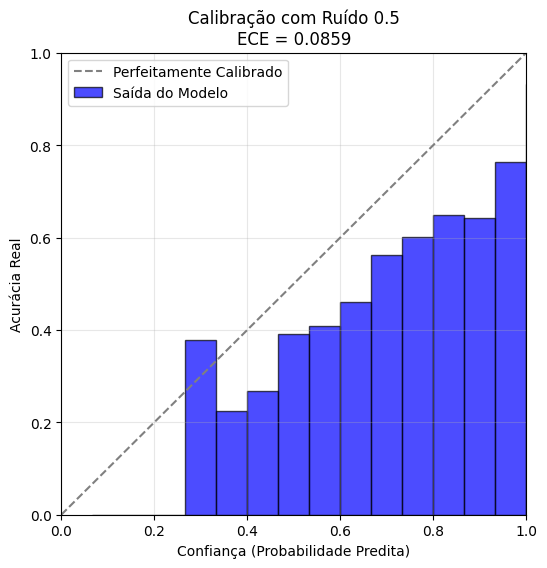

In [56]:
# 2. Calcular para modelo com Ruído (ex: severidade 0.5)
probs_noise, labels_noise = get_logits_and_labels(
    model_loaded, loader_pt_test, device, 
    corruption_func=apply_gaussian_noise, severity=0.5
)
ece_noise = calc_and_plot_ece(probs_noise, labels_noise, title="Calibração com Ruído 0.5")

## Teste de Desfoque

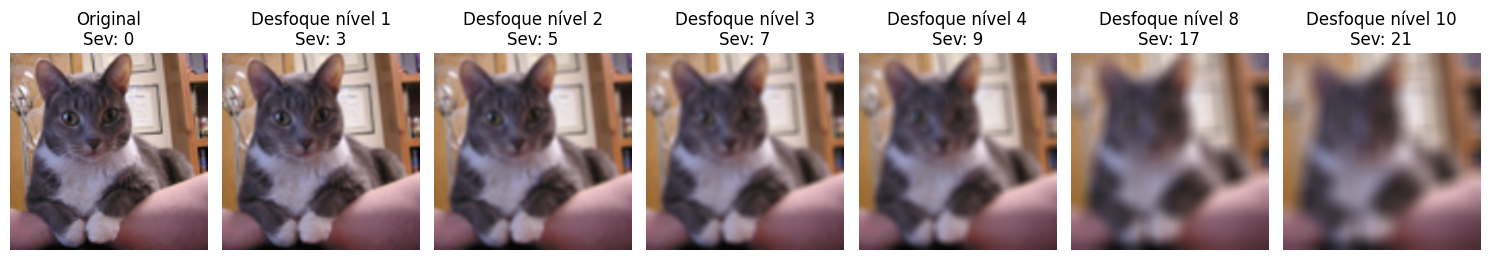

In [49]:
# Lista de testes para visualizar
tests_noise = [
    ("Original", None, 0),
    ("Desfoque nível 1", apply_blur, 3),
    ("Desfoque nível 2", apply_blur, 5),
    ("Desfoque nível 3", apply_blur, 7),
    ("Desfoque nível 4", apply_blur, 9),
    ("Desfoque nível 8", apply_blur, 17),
    ("Desfoque nível 10", apply_blur, 21),
]

visualize_corruptions(loader_pt_test, stats_stl10, tests_noise, img_idx=4)


>> Iniciando avaliação: Gaussian Blur
   Severidade 0: 95.20%
   Severidade 3: 94.26%
   Severidade 5: 91.30%
   Severidade 7: 86.12%
   Severidade 9: 76.80%
   Severidade 11: 63.46%
   Severidade 13: 49.21%
   Severidade 15: 37.94%
   Severidade 17: 30.39%
   Severidade 19: 24.94%
   Severidade 21: 21.34%
   [Gráfico salvo em: images/resultado_robustez_blur.png]


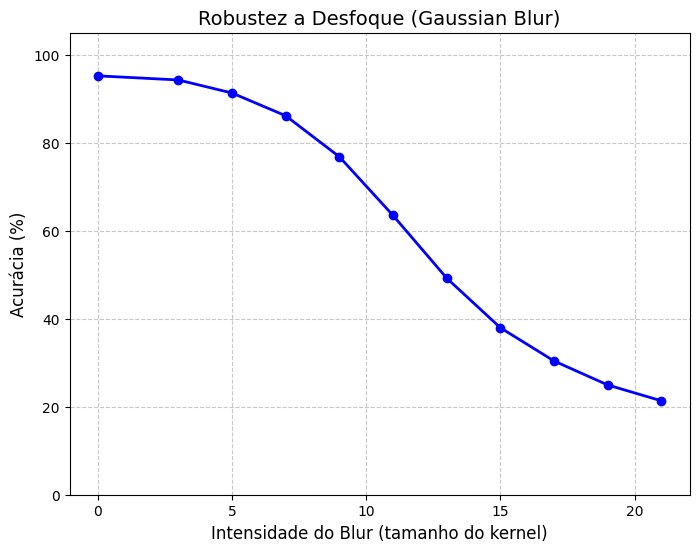

In [47]:
severities_blur = [0, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

# 1. Avaliar
acc_blur = evaluate_model(
    model=model_loaded,
    loader=loader_pt_test,
    corruption_func=apply_blur,
    severities=severities_blur,
    device=device,
    corruption_name="Gaussian Blur"
)

# 2. Plotar e Salvar
plot_acc_curve(
    x_values=severities_blur,
    y_values=acc_blur,
    title="Robustez a Desfoque (Gaussian Blur)",
    xlabel="Intensidade do Blur (tamanho do kernel)",
    color='blue',
    filename='images/resultado_robustez_blur.png'
)

plt.show()

   [Gráfico de retenção salvo em: images/robustez_relativa_desfoque.png]


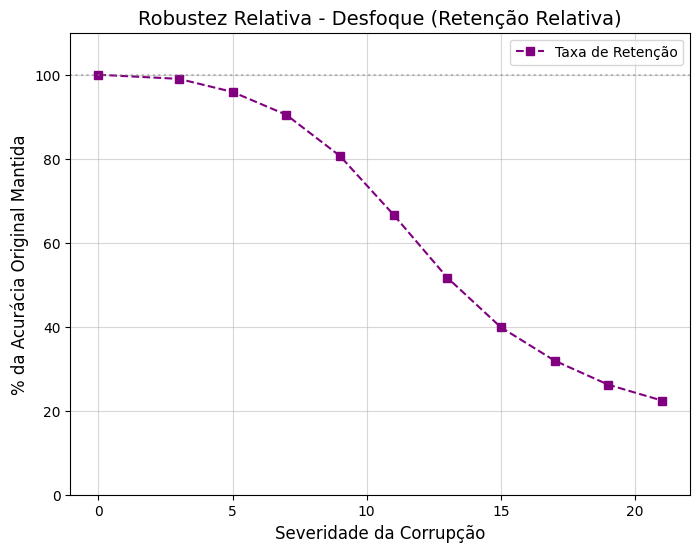

In [48]:
baseline_acc = acc_blur[0] 

plot_relative_robustness(
    clean_acc=baseline_acc, 
    corrupted_accs=acc_blur, 
    severities=severities_blur,
    title="Robustez Relativa - Desfoque", 
    filename="images/robustez_relativa_desfoque.png"
)

plt.show()

Coletando probabilidades...

--- Calculando ECE (Calibração com Desfoque com kernel 11) ---
ECE Score: 0.0974 (Quanto menor, melhor)


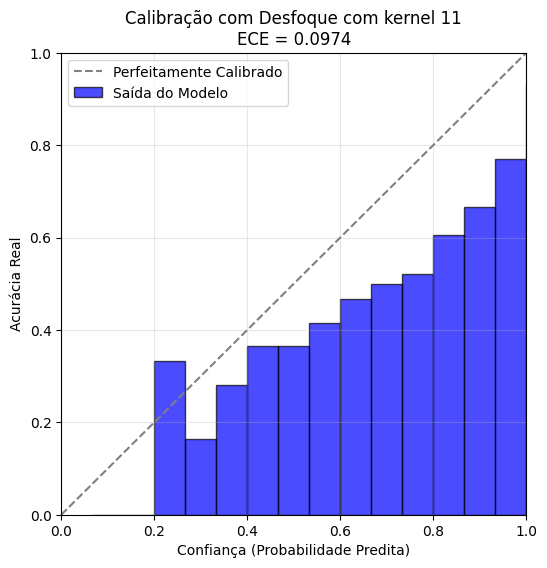

In [58]:
# 2. Calcular para modelo com Ruído (ex: severidade 0.5)
probs_noise, labels_noise = get_logits_and_labels(
    model_loaded, loader_pt_test, device, 
    corruption_func=apply_blur, severity= 11
)
ece_noise = calc_and_plot_ece(probs_noise, labels_noise, title="Calibração com Desfoque com kernel 11")

## Teste de Diminuição de brilho

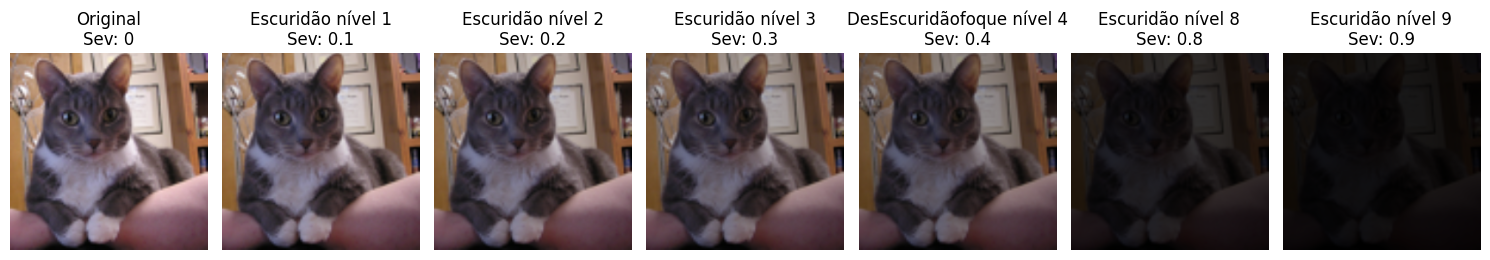

In [92]:
# Lista de testes para visualizar
tests_noise = [
    ("Original", None, 0),
    ("Escuridão nível 1", apply_darkness, 0.1),
    ("Escuridão nível 2", apply_darkness, 0.2),
    ("Escuridão nível 3", apply_darkness, 0.3),
    ("DesEscuridãofoque nível 4", apply_darkness, 0.4),
    ("Escuridão nível 8", apply_darkness, 0.8),
    ("Escuridão nível 9", apply_darkness, 0.9),
]

visualize_corruptions(loader_pt_test, stats_stl10, tests_noise, img_idx=4)

In [84]:
severities_bright = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# 1. Avaliar
acc_bright = evaluate_model(
    model=model_loaded,
    loader=loader_pt_test,
    corruption_func=apply_darkness,
    severities=severities_bright,
    device=device,
    stats=stats_stl10,
    corruption_name="Diminuição de Brilho"
)


>> Iniciando avaliação: Diminuição de Brilho
   Severidade 0.0: 95.20%
   Severidade 0.1: 94.99%
   Severidade 0.2: 94.72%
   Severidade 0.3: 94.38%
   Severidade 0.4: 94.01%
   Severidade 0.5: 93.00%
   Severidade 0.6: 91.30%
   Severidade 0.7: 87.50%
   Severidade 0.8: 74.95%
   Severidade 0.9: 28.16%


   [Gráfico salvo em: images/resultado_robustez_brightness_drop.png]


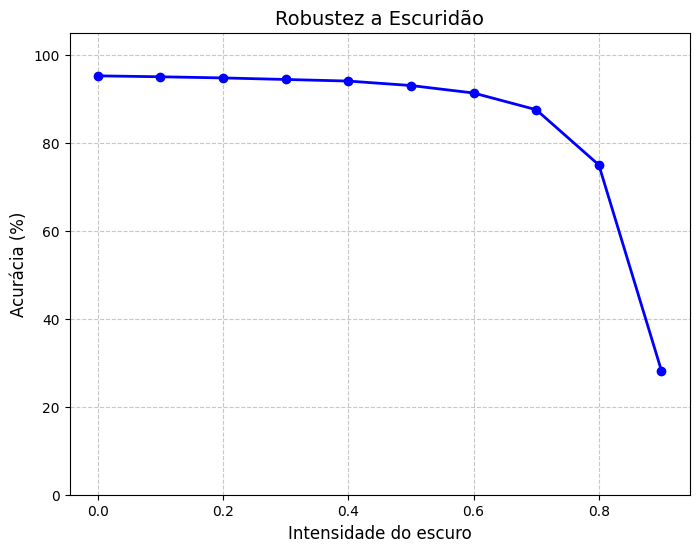

In [86]:
plot_acc_curve(
    x_values=severities_bright,
    y_values=acc_bright,
    title="Robustez a Escuridão",
    xlabel="Intensidade do escuro",
    color='blue',
    filename='images/resultado_robustez_brightness_drop.png'
)

Coletando probabilidades...

--- Calculando ECE (Calibração com Diminuição de brilho 0.8) ---
ECE Score: 0.0974 (Quanto menor, melhor)


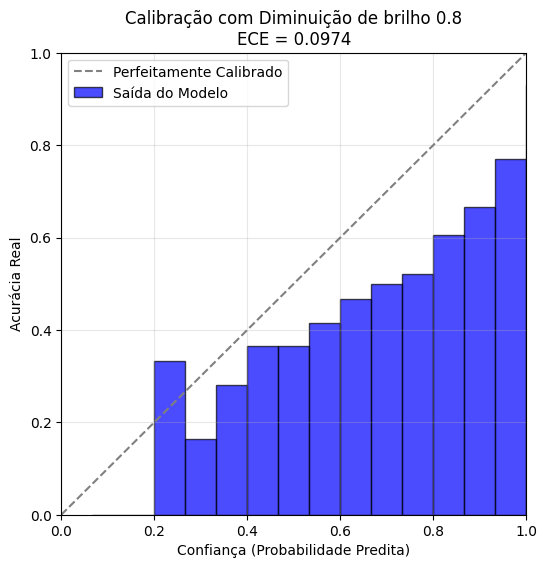

In [89]:
probs_darkness, labels_darkness = get_logits_and_labels(
    model_loaded, loader_pt_test, device, 
    corruption_func=apply_darkness, severity=0.8
)
ece_darkness = calc_and_plot_ece(probs_noise, labels_noise, title="Calibração com Diminuição de brilho 0.8")